In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd

df_d = pd.read_csv(    r"C:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_data_dewastacja_.csv")
df_poz=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_data_pozar_.csv")
df_gaz=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_data_Zangaz_.csv")
df_pyl=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_data_Zanpyl_.csv")
df_zat=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_data_zatrudnienie_.csv")
df_il=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_datailosc_2024_.csv")
df_war=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_datawartosc_2024_.csv")
df_las=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_powlas_2024_.csv")
df_lasch=pd.read_csv(    r"c:\Users\ALEX\OneDrive\Pulpit\Analiza Python\bdl_powlaschro_2024_.csv")


In [14]:
dfs = [df_d, df_poz, df_gaz, df_pyl, df_zat, df_il, df_war, df_las, df_lasch]
new_names = [
    "Dewastacja",
    "Pozary",
    "Za_gaz",
    "Za-pyl",
    "Zatrudnienie",
    "Ilosc",
    "Wartosc",
    "P_lasy",
    "P_lasy_ch"
]
for df, new_name in zip(dfs, new_names):
    df.rename(columns={"Value": new_name}, inplace=True)
for i, df in enumerate(dfs, start=1):
    print(f"df{i}:", df.columns.tolist())



df1: ['Region', 'Year', 'Dewastacja']
df2: ['Region', 'Year', 'Pozary']
df3: ['Region', 'Year', 'Za_gaz']
df4: ['Region', 'Year', 'Za-pyl']
df5: ['Region', 'Year', 'Zatrudnienie']
df6: ['Region', 'Year', 'Ilosc']
df7: ['Region', 'Year', 'Wartosc']
df8: ['Region', 'Year', 'P_lasy']
df9: ['Region', 'Year', 'P_lasy_ch']


In [15]:
for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {df['Year'].min()}–{df['Year'].max()}")
   


df1: 2005–2020
df2: 2009–2024
df3: 1998–2024
df4: 1996–2024
df5: 2010–2024
df6: 2009–2024
df7: 2009–2024
df8: 1998–2024
df9: 1998–2024


In [17]:
for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[
        (dfs[i]["Year"] >= 2016) &
        (dfs[i]["Year"] <= 2020)
    ].copy()

for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {sorted(df['Year'].unique())}")


df1: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df2: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df3: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df4: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df5: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df6: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df7: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df8: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df9: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [19]:
from functools import reduce

df_all = reduce(
    lambda left, right: left.merge(
        right,
        on=["Region", "Year"],
        how="inner"
    ),
    dfs
)

print(df_all.shape)
print(df_all.head())



(80, 11)
        Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1  MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2  MAŁOPOLSKIE  2018        52.7   236.0  10483040.0  1841.0          52.3   
3  MAŁOPOLSKIE  2019        54.5   190.0   8996236.0  1635.0          53.5   
4  MAŁOPOLSKIE  2020        56.9   176.0   7002044.0  1088.0          53.5   

   Ilosc  Wartosc     P_lasy  P_lasy_ch  
0   22.0    469.0  202140.16   18043.51  
1   16.0    196.7  202078.00   18112.17  
2    9.0    101.0  201366.39   18143.25  
3   27.0    231.9  201241.09   18197.84  
4   18.0    198.6  201200.81   18238.77  


In [ ]:
#braki
df_all.isna().sum()  
#duikaty
df_all.duplicated(["Region", "Year"]).sum()


np.int64(0)

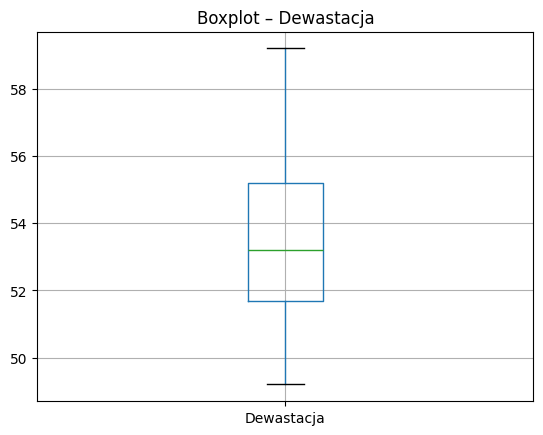

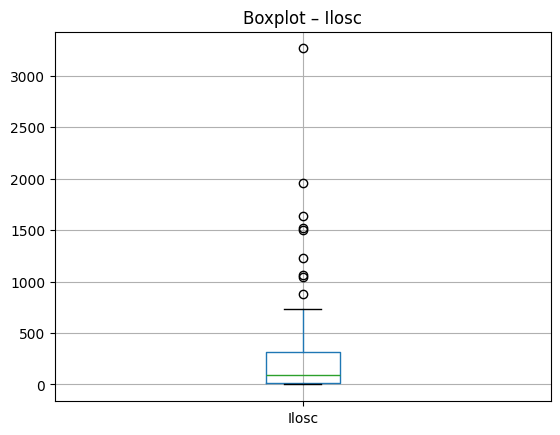

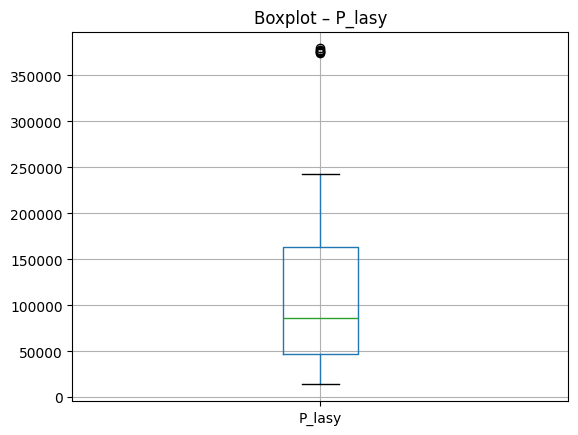

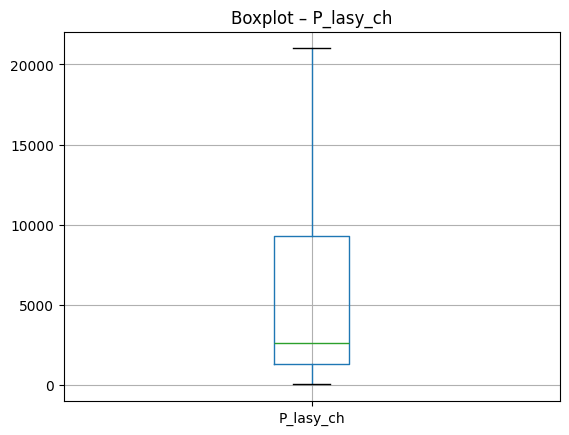

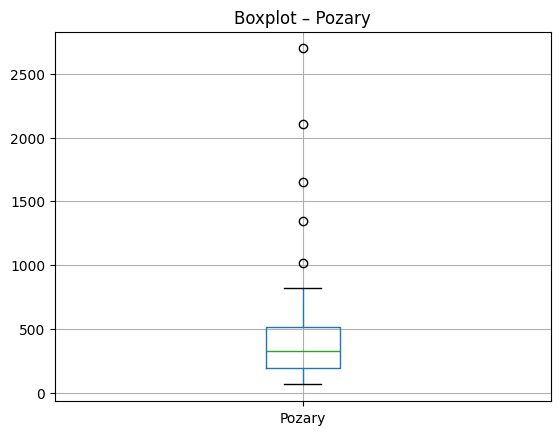

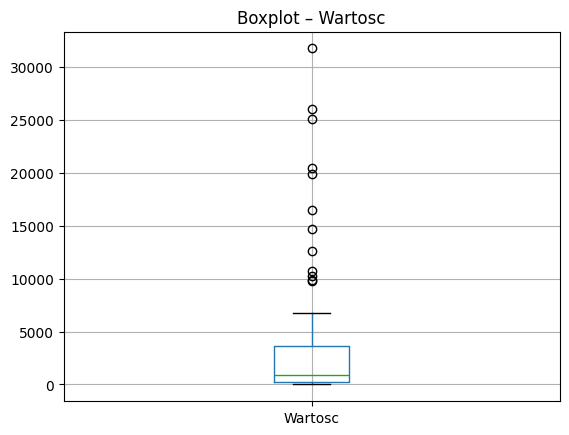

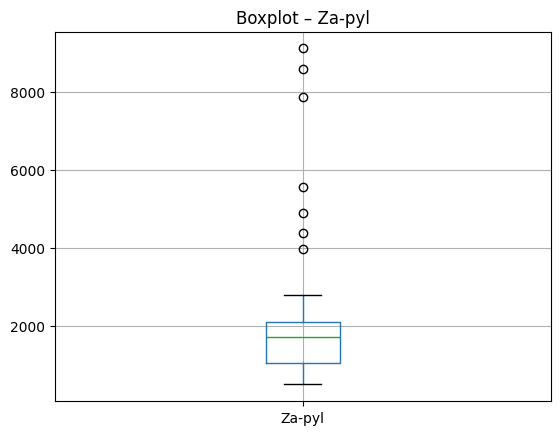

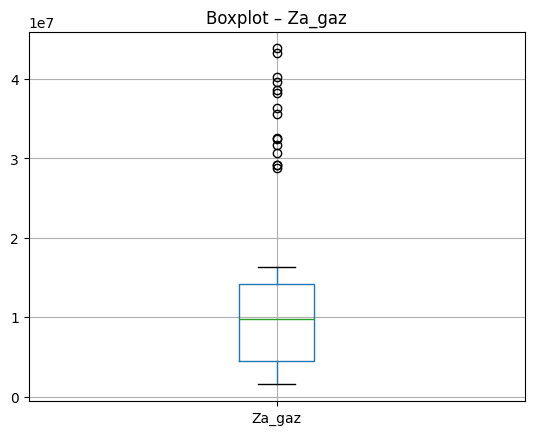

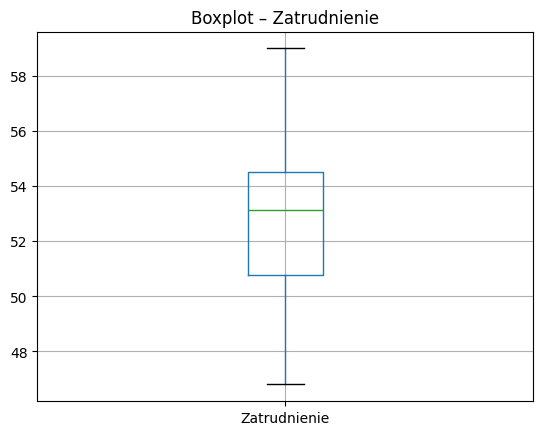

In [21]:
cols_to_plot = df_all.columns.difference(["Region", "Year"])

import matplotlib.pyplot as plt

for col in cols_to_plot:
    plt.figure()
    df_all.boxplot(column=col)
    plt.title(f"Boxplot – {col}")
    plt.show()


In [22]:
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)].copy()
    outliers["Zmienna"] = col
    outliers["Dolna_granica"] = lower
    outliers["Gorna_granica"] = upper

    return outliers


In [26]:
outlier_list = []

for col in cols_to_plot:
    out = iqr_outliers(df_all, col)
    outlier_list.append(out)

outliers_df = pd.concat(outlier_list, ignore_index=True)

outliers_df = outliers_df[
    ["Zmienna", "Region", "Year", col]
]
outliers_df.groupby("Zmienna").size()
print(outliers_df)



    Zmienna               Region  Year  Zatrudnienie
0     Ilosc             LUBUSKIE  2017          53.7
1     Ilosc             LUBUSKIE  2019          54.5
2     Ilosc        WIELKOPOLSKIE  2016          55.2
3     Ilosc        WIELKOPOLSKIE  2017          57.2
4     Ilosc        WIELKOPOLSKIE  2018          57.7
5     Ilosc        WIELKOPOLSKIE  2019          57.5
6     Ilosc            POMORSKIE  2016          54.6
7     Ilosc            POMORSKIE  2017          56.0
8     Ilosc            POMORSKIE  2019          58.1
9    P_lasy          MAZOWIECKIE  2016          56.2
10   P_lasy          MAZOWIECKIE  2017          57.2
11   P_lasy          MAZOWIECKIE  2018          58.4
12   P_lasy          MAZOWIECKIE  2019          59.0
13   P_lasy          MAZOWIECKIE  2020          58.6
14   Pozary          MAZOWIECKIE  2016          56.2
15   Pozary          MAZOWIECKIE  2017          57.2
16   Pozary          MAZOWIECKIE  2018          58.4
17   Pozary          MAZOWIECKIE  2019        